# Simple Neural Network — Workout Effectiveness Classifier

This is my reworked version of the "Coffee Roasting" lab from the *Advanced Learning Algorithms* course (Machine Learning Specialization, DeepLearning.AI / Coursera). The original built a small 2-layer neural network to classify a "good" vs "bad" coffee roast from temperature and duration.

Here I've rebuilt the same concept with a **different dataset and domain**: classifying whether a workout was "effective" based on **duration (minutes)** and **peak heart rate (bpm)**. The underlying idea is identical — two features, a non-linear "good zone," and a small neural network (3 sigmoid units → 1 sigmoid unit) that learns to carve out that zone on its own.

This notebook is fully self-contained — data generation and all plotting functions are written from scratch below, with no dependency on the course's private utility files.

**Goals:**
- Generate a synthetic 2-feature classification dataset with a non-trivial "good zone"
- Build and train a small 2-layer neural network in Keras
- Inspect what each hidden unit has learned
- Visualize the network's final decision boundary

## Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=2)

I0000 00:00:1786874230.090946     584 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786874230.262053     584 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786874231.824707     584 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Dataset

Instead of temperature vs. roasting duration, I'm generating a synthetic dataset of **workout duration (minutes)** vs. **peak heart rate (bpm)**, labeling a workout "effective" (1) if it falls in a sensible zone: a moderate-to-vigorous heart rate sustained for a reasonable duration, with a trade-off between the two (a very high heart rate is only "safe/effective" for a shorter duration, and vice versa) — similar in spirit to the coffee lab's diagonal cutoff between temperature and time.

In [2]:
def load_workout_data():
    """
    Synthetic workout-effectiveness dataset.
    Features: [duration_minutes, peak_heart_rate_bpm]
    Label: 1 = effective workout, 0 = not effective
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1, 2)
    X[:, 0] = X[:, 0] * (65 - 15) + 15    # duration: 15-65 minutes
    X[:, 1] = X[:, 1] * (190 - 90) + 90   # heart rate: 90-190 bpm

    Y = np.zeros(len(X))
    for i, (duration, hr) in enumerate(X):
        # diagonal trade-off: allowed duration shrinks as heart rate rises
        max_duration_for_hr = -0.15 * hr + 55
        if (110 < hr < 175) and (25 < duration < 55) and (duration <= max_duration_for_hr):
            Y[i] = 1

    return X, Y.reshape(-1, 1)


X, Y = load_workout_data()
print(X.shape, Y.shape)

(200, 2) (200, 1)


Duration is best kept in a moderate range (not too short to matter, not so long it risks overtraining), while heart rate should sit in a moderate-to-vigorous zone. As heart rate climbs, the "safe/effective" duration window shrinks — this is the non-linear relationship the network will have to learn.

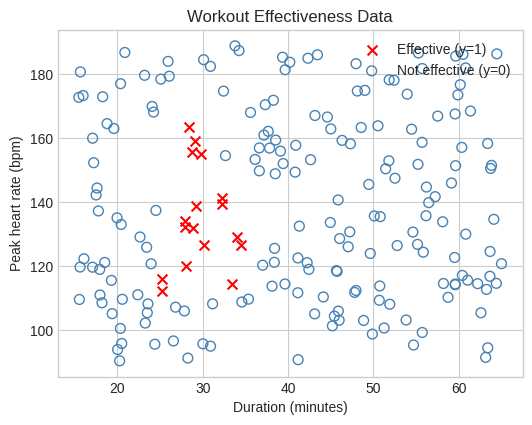

In [3]:
def plot_data(X, Y, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
    pos = Y[:, 0] == 1
    neg = Y[:, 0] == 0
    ax.scatter(X[pos, 0], X[pos, 1], marker='x', c='red', s=50, label='Effective (y=1)')
    ax.scatter(X[neg, 0], X[neg, 1], marker='o', facecolors='none', edgecolors='steelblue',
               s=50, label='Not effective (y=0)')
    ax.set_xlabel('Duration (minutes)')
    ax.set_ylabel('Peak heart rate (bpm)')
    ax.legend(loc='upper right')
    return ax

plot_data(X, Y)
plt.title('Workout Effectiveness Data')
plt.show()

### Normalize data

Just like in the original lab, we normalize the features using a Keras `Normalization` layer so training converges faster. This layer isn't part of the model itself — it's applied once up front (and must be applied to any future data the model sees too).

In [4]:
print(f"Duration   Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Heart rate Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")

norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)
Xn = norm_l(X)

print(f"Duration   Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Heart rate Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Duration   Max, Min pre normalization: 65.00, 15.49
Heart rate Max, Min pre normalization: 188.86, 90.32


Duration   Max, Min post normalization: 1.66, -1.69
Heart rate Max, Min post normalization: 1.79, -1.70


We tile the data to increase the effective training set size, which reduces the number of epochs needed.

In [5]:
Xt = np.tile(Xn, (1000, 1))
Yt = np.tile(Y, (1000, 1))
print(Xt.shape, Yt.shape)

(200000, 2) (200000, 1)


## TensorFlow model

A small 2-layer network: 3 sigmoid units in the first layer, 1 sigmoid unit in the output layer — the same architecture as the coffee roasting lab, just applied to this new dataset.

In [6]:
tf.random.set_seed(1234)
model = Sequential([
    tf.keras.Input(shape=(2,)),
    Dense(3, activation='sigmoid', name='layer1'),
    Dense(1, activation='sigmoid', name='layer2'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

The parameter counts match what we'd expect by hand:

In [7]:
L1_num_params = 2 * 3 + 3   # W1 + b1
L2_num_params = 3 * 1 + 1   # W2 + b2
print("L1 params =", L1_num_params, ", L2 params =", L2_num_params)

L1 params = 9 , L2 params = 4


In [8]:
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[-0.08 -0.97 -0.65]
 [ 0.04  0.45  0.86]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[-0.04]
 [ 0.93]
 [ 0.53]] 
b2(1,): [0.]


### Train

`model.compile` sets the loss and optimizer, and `model.fit` runs gradient descent to fit the weights — the details of both are covered later in the specialization. For now, the takeaway is just that the network learns its own weights from the data.

In [9]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
)

model.fit(Xt, Yt, epochs=10)

Epoch 1/10


   1/6250 ━━━━━━━━━━━━━━━━━━━━ 1:05:41 631ms/step - loss: 1.1397

  49/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.7365       

  99/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.5685

 150/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.4852

...

6090/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - loss: 6.0113e-08

6142/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - loss: 5.9898e-08

6190/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - loss: 5.9627e-08

6241/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - loss: 5.9473e-08

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 999us/step - loss: 5.9410e-08


After training, the weights have moved from their random initial values to values that (hopefully) let the network separate effective from ineffective workouts.

In [10]:
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[  6.93 -15.74  31.95]
 [-20.72   1.91   7.14]] 
b1: [-15.4  -15.72  14.68]
W2:
 [[-57.13]
 [-66.34]
 [-53.21]] 
b2: [30.49]


## Predictions

Let's test the trained model on a couple of new examples. Remember: any new input has to go through the same normalization as the training data.

In [11]:
X_test = np.array([
    [35, 140],   # moderate duration, moderate heart rate -> expect effective
    [50, 170],   # long duration + high heart rate -> expect not effective
])
X_testn = norm_l(X_test)
predictions = model.predict(X_testn, verbose=0)
print("predictions =\n", predictions)

predictions =
 [[7.60e-10]
 [1.36e-10]]


Converting probabilities to decisions with a 0.5 threshold:

In [12]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions =\n{yhat}")

decisions =
[[0]
 [0]]


## Layer functions

Let's look at what each of the 3 first-layer units learned by shading its output over the full (duration, heart rate) grid. Each unit is its own little logistic classifier — the network combines their outputs in the second layer to make the final call.

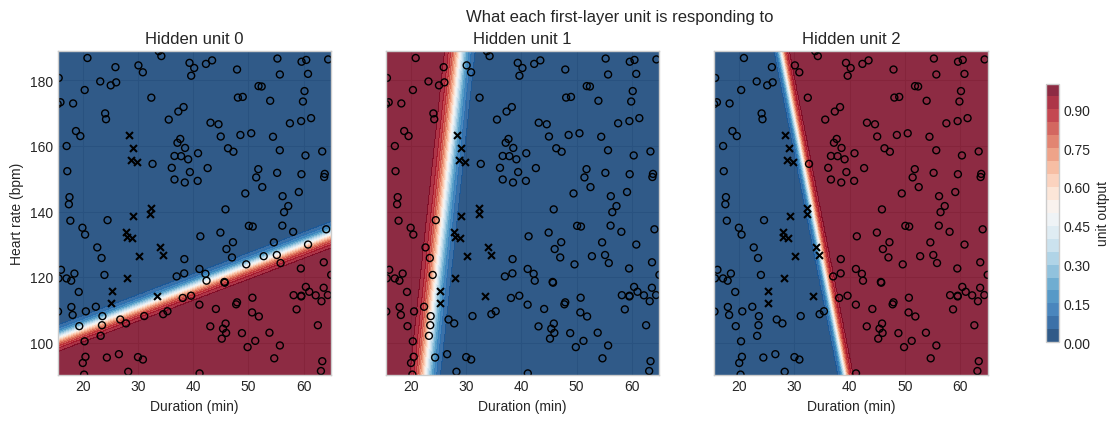

In [13]:
def plt_layer1_units(X, Y, W1, b1, norm_l):
    d_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    hr_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
    Dg, HRg = np.meshgrid(d_range, hr_range)
    grid = np.c_[Dg.ravel(), HRg.ravel()]
    grid_n = norm_l(grid)

    z = 1 / (1 + np.exp(-(grid_n.numpy() @ W1 + b1)))  # sigmoid(W1.x + b1) for all 3 units at once

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
    pos = Y.flatten() == 1
    neg = Y.flatten() == 0
    for unit in range(3):
        ax = axes[unit]
        cs = ax.contourf(Dg, HRg, z[:, unit].reshape(Dg.shape), levels=20, cmap='RdBu_r', alpha=0.85)
        ax.scatter(X[pos, 0], X[pos, 1], marker='x', c='black', s=25)
        ax.scatter(X[neg, 0], X[neg, 1], marker='o', facecolors='none', edgecolors='black', s=25)
        ax.set_title(f"Hidden unit {unit}")
        ax.set_xlabel("Duration (min)")
    axes[0].set_ylabel("Heart rate (bpm)")
    fig.suptitle("What each first-layer unit is responding to")
    fig.colorbar(cs, ax=axes, shrink=0.8, label="unit output")
    plt.show()

plt_layer1_units(X, Y, W1, b1, norm_l)

Each unit tends to specialize in flagging a different way a workout can be *ineffective* — e.g. one leaning on heart rate being too low, another on duration being off, another capturing the diagonal trade-off region. The network discovered this division of labor purely through gradient descent, without being told to.

### Output layer weights

The output unit combines the three hidden-unit signals. A quick look at its weights tells us how much each hidden unit contributes and in which direction (negative weights here mean "high hidden-unit output pushes prediction toward 0").

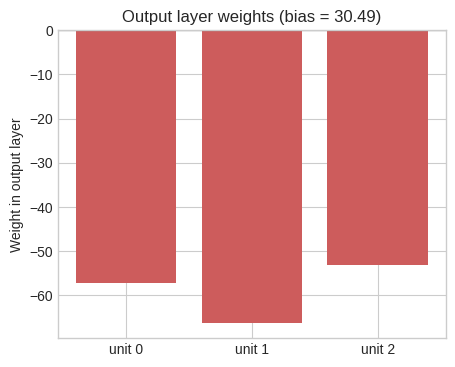

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
units = [f"unit {i}" for i in range(3)]
colors = ['steelblue' if w >= 0 else 'indianred' for w in W2.flatten()]
ax.bar(units, W2.flatten(), color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel("Weight in output layer")
ax.set_title(f"Output layer weights (bias = {b2[0]:.2f})")
plt.show()

## The full network's decision boundary

Finally, let's look at the network as a whole: its raw probability output across the full input space, and the thresholded (0.5 cutoff) decision it produces.

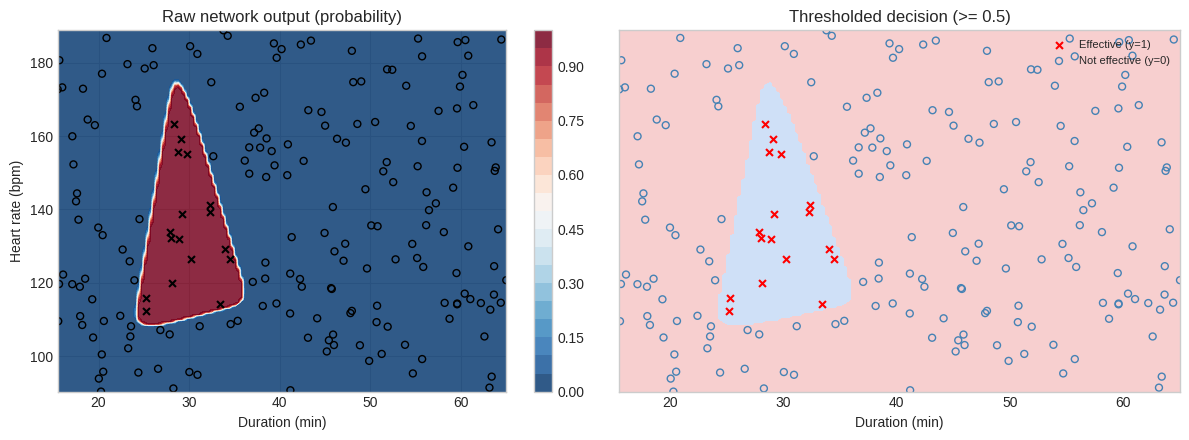

In [15]:
def plt_network_decision(X, Y, model, norm_l):
    d_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 150)
    hr_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 150)
    Dg, HRg = np.meshgrid(d_range, hr_range)
    grid = np.c_[Dg.ravel(), HRg.ravel()]
    probs = model.predict(norm_l(grid), verbose=0).reshape(Dg.shape)

    pos = Y[:, 0] == 1
    neg = Y[:, 0] == 0

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

    cs = axes[0].contourf(Dg, HRg, probs, levels=20, cmap='RdBu_r', alpha=0.85)
    axes[0].scatter(X[pos, 0], X[pos, 1], marker='x', c='black', s=25)
    axes[0].scatter(X[neg, 0], X[neg, 1], marker='o', facecolors='none', edgecolors='black', s=25)
    axes[0].set_title("Raw network output (probability)")
    axes[0].set_xlabel("Duration (min)")
    axes[0].set_ylabel("Heart rate (bpm)")
    fig.colorbar(cs, ax=axes[0])

    axes[1].contourf(Dg, HRg, probs >= 0.5, levels=[-0.5, 0.5, 1.5], colors=['#f7cfcf', '#cfe0f7'])
    axes[1].scatter(X[pos, 0], X[pos, 1], marker='x', c='red', s=25, label='Effective (y=1)')
    axes[1].scatter(X[neg, 0], X[neg, 1], marker='o', facecolors='none', edgecolors='steelblue', s=25, label='Not effective (y=0)')
    axes[1].set_title("Thresholded decision (>= 0.5)")
    axes[1].set_xlabel("Duration (min)")
    axes[1].legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

plt_network_decision(X, Y, model, norm_l)

The left plot shows the network's raw confidence across the whole input space, and the right plot shows the final effective/not-effective call after applying the 0.5 threshold. The learned region roughly matches the diagonal "good zone" the synthetic data was generated with — even though the network was never told the rule directly, only shown labeled examples.

## What I learned

- A small neural network (few sigmoid units per layer) can learn a non-linear decision boundary that a single neuron/logistic regression couldn't represent on its own.
- Each hidden unit tends to specialize — the network divides the classification problem into simpler sub-decisions and recombines them in the output layer, all learned automatically via gradient descent.
- Feature normalization (via a `Normalization` layer, fit only on the training data) matters for how quickly and reliably training converges.
- Visualizing intermediate hidden-unit activations is a useful way to build intuition for what's actually happening inside a small network, instead of treating it as a black box.

*Original lab: "Simple Neural Network" (Coffee Roasting) — Machine Learning Specialization (DeepLearning.AI / Coursera). Dataset, data-generation logic, and all plotting functions rewritten by me for practice.*